<a href="https://colab.research.google.com/github/miiduwww19/StockWebScraping/blob/main/WebScrappingStockMarket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf

In [ ]:
import pandas as pd

In [ ]:
# Set the stock ticker symbol
stock_symbol = 'COMI.CA'

In [ ]:
# Download stock data from Yahoo Finance
stock_data = yf.download(stock_symbol, start='2020-01-01', end='2023-01-01')

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Download stock data from Yahoo Finance
stock_data_until_june_2024 = yf.download(stock_symbol, start='2020-01-01', end='2024-06-01')


[*********************100%***********************]  1 of 1 completed


In [ ]:
# Show the first few rows of data
stock_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,41.388321,41.552837,41.129086,41.428204,38.707844,570963
2020-01-05,41.428204,40.879818,40.132015,40.311489,37.664463,1679811
2020-01-06,40.311489,40.630550,39.932602,40.356358,37.706387,1865728
2020-01-08,40.356358,41.727325,39.947559,41.378349,38.661266,4145684
2020-01-09,41.378349,41.926739,41.378349,41.722340,38.982670,5606714


In [ ]:
stock_data_until_june_2024.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,41.388321,41.552837,41.129086,41.428204,38.707848,570963
2020-01-05,41.428204,40.879818,40.132015,40.311489,37.664463,1679811
2020-01-06,40.311489,40.630550,39.932602,40.356358,37.706383,1865728
2020-01-08,40.356358,41.727325,39.947559,41.378349,38.661270,4145684
2020-01-09,41.378349,41.926739,41.378349,41.722340,38.982670,5606714


In [ ]:
# Assuming 'stock_data_until_june_2024' is a pandas DataFrame and 'column_name' is the column you want to sort by
sorted_data = stock_data_until_june_2024.sort_values(by='Date', ascending=False)

# To display the first few rows after sorting
sorted_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-05-30,76.550003,78.199997,73.010002,78.199997,78.199997,17254438
2024-05-29,76.709999,77.480003,76.309998,76.550003,76.550003,1745632
2024-05-28,76.500000,78.199997,75.099998,76.709999,76.709999,3345349
2024-05-27,77.000000,77.500000,76.349998,76.500000,76.500000,284386
2024-05-26,76.000000,76.000000,76.000000,76.000000,76.000000,0


In [ ]:
import matplotlib.pyplot as plt


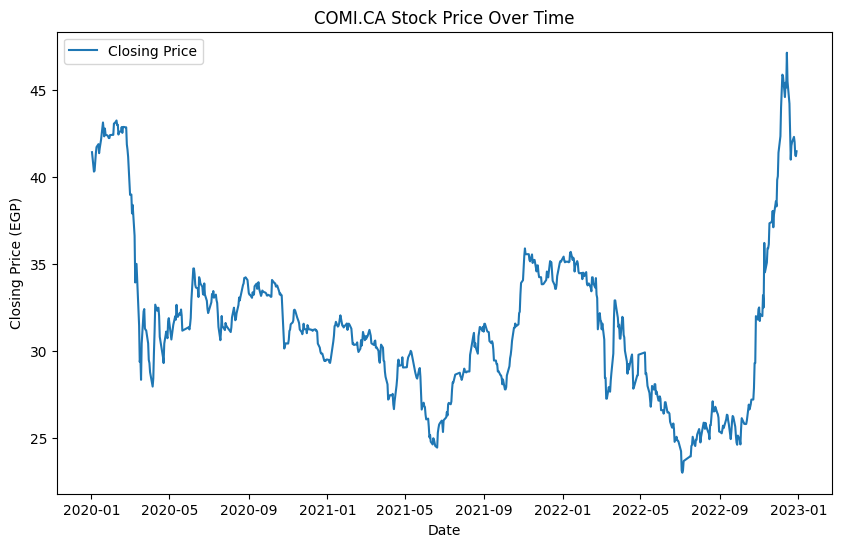

In [ ]:
# Plot the closing price over time
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Closing Price')
plt.title(f"{stock_symbol} Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (EGP)")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
# Prepare the data
stock_data['Date'] = pd.to_datetime(stock_data.index).map(pd.Timestamp.toordinal)
X = stock_data[['Date']]
y = stock_data['Close']

In [ ]:
# Prepare the data
stock_data_until_june_2024['Date'] = pd.to_datetime(stock_data_until_june_2024.index).map(pd.Timestamp.toordinal)
X = stock_data_until_june_2024[['Date']]
y = stock_data_until_june_2024['Close']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Make predictions
predictions = model.predict(X_test)

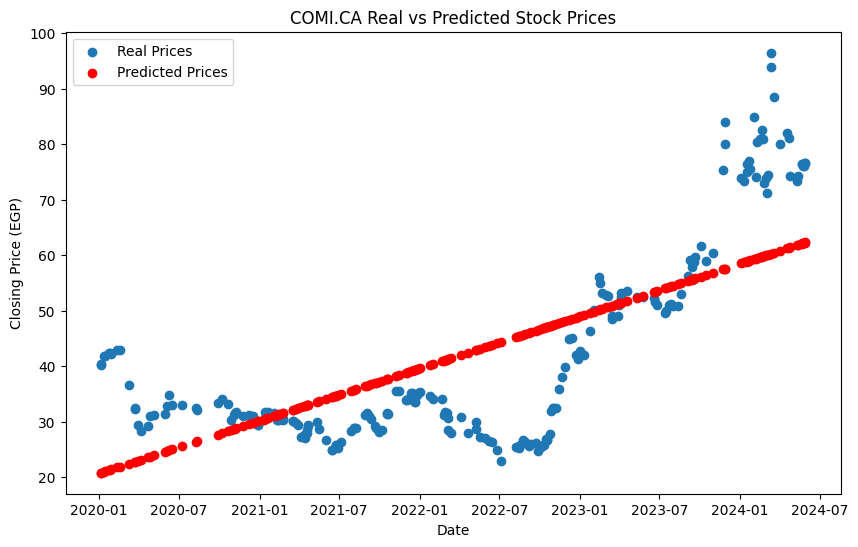

In [ ]:
# Plot the real vs predicted closing prices
plt.figure(figsize=(10, 6))
plt.scatter(X_test.index, y_test, label="Real Prices")
plt.scatter(X_test.index, predictions, label="Predicted Prices", color='red')
plt.title(f"{stock_symbol} Real vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price (EGP)")
plt.legend()
plt.show()

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)

Mean Squared Error: 147.9069207644662


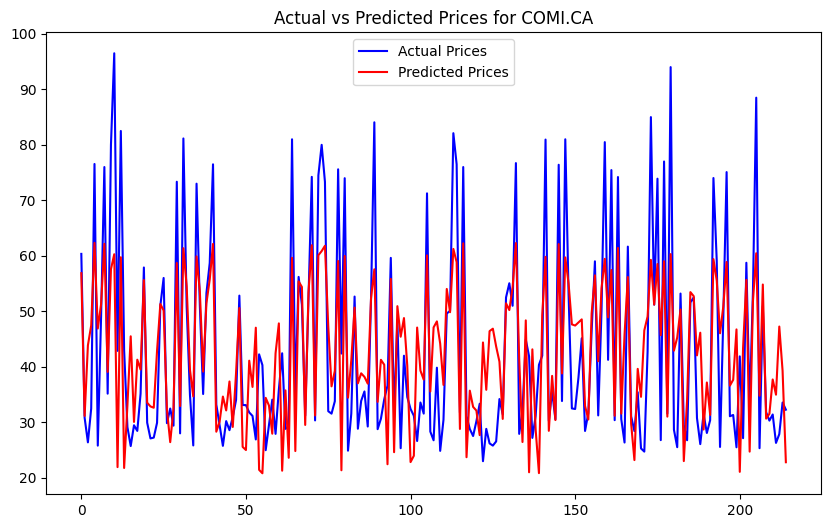

In [ ]:
from sklearn.metrics import mean_squared_error
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Plot actual vs predicted prices
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual Prices', color='b')
plt.plot(y_pred, label='Predicted Prices', color='r')
plt.legend()
plt.title(f'Actual vs Predicted Prices for {stock_symbol}')
plt.show()